# 05 — Comparative Analysis: Germany vs Netherlands

Compare motorway accident safety between:
- 🇩🇪 **Unlimited Autobahn** (no speed limit sections)
- 🇩🇪 **Speed-limited Autobahn** (100/120/130 km/h limit)
- 🇳🇱 **Dutch motorways** (autosnelwegen, 100/130 km/h)

Main metric: **fatalities per 1000 accidents** (severity index).
With vehicle-km normalisation where available.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sys.path.insert(0, "../src")


DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")
sns.set_theme(style="whitegrid")
print("Ready.")

Ready.


## 1. Load processed data from notebooks 03 and 04

In [2]:
classified_path = DATA_PROC / "unfallatlas_classified.parquet"
if classified_path.exists():
    df_de = pd.read_parquet(classified_path)
    print(f"Germany: {len(df_de):,} accident records")
else:
    print("Run notebook 03 first.")
    df_de = None

nl_path = DATA_PROC / "rws_motorway_annual.parquet"
if nl_path.exists():
    df_nl_annual = pd.read_parquet(nl_path)
    print(f"Netherlands: {len(df_nl_annual)} years")
else:
    print("Run notebook 04 first.")
    df_nl_annual = None

Germany: 2,098,019 accident records
Netherlands: 15 years


## 2. Severity index comparison (fatalities per 1000 accidents)

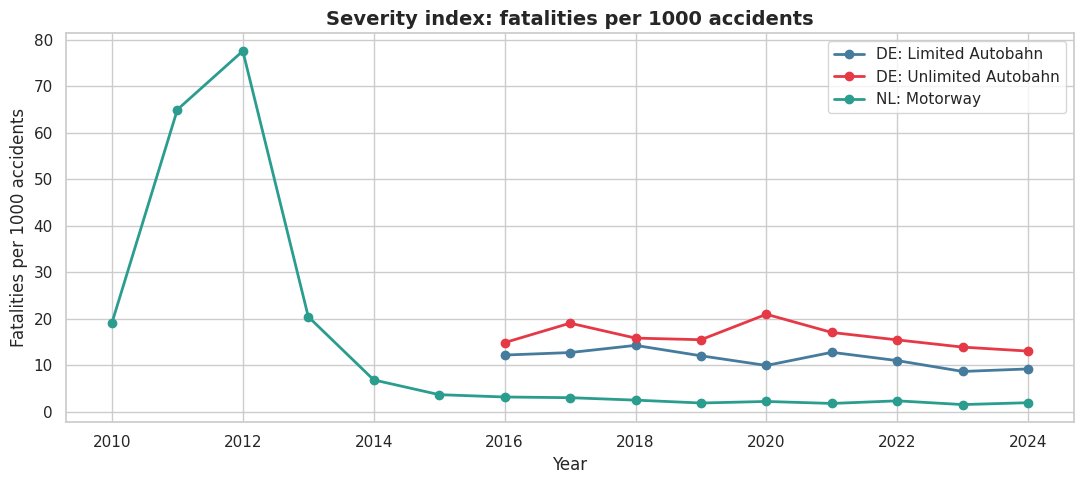

In [3]:
if df_de is not None:
    de_groups = {
        "DE: Unlimited Autobahn": df_de[df_de["on_unlimited"]],
        "DE: Limited Autobahn": df_de[df_de["on_limited_mw"]],
    }
    de_annual = []
    for label, grp in de_groups.items():
        by_year = (
            grp.groupby("year")
            .agg(
                total=("severity", "count"),
                fatal=("severity", lambda x: (x == "fatal").sum()),
            )
            .reset_index()
        )
        by_year["group"] = label
        by_year["severity_idx"] = by_year["fatal"] / by_year["total"]
        de_annual.append(by_year)
    df_de_annual = pd.concat(de_annual)

    if df_nl_annual is not None:
        df_nl_plot = df_nl_annual[["year", "total", "fatal", "severity_idx"]].copy()
        df_nl_plot["group"] = "NL: Motorway"
        df_combined = pd.concat([df_de_annual, df_nl_plot], ignore_index=True)

        palette = {
            "DE: Unlimited Autobahn": "#e63946",
            "DE: Limited Autobahn": "#457b9d",
            "NL: Motorway": "#2a9d8f",
        }
        fig, ax = plt.subplots(figsize=(11, 5))
        for grp_name, grp in df_combined.groupby("group"):
            ax.plot(
                grp["year"],
                grp["severity_idx"] * 1000,
                marker="o",
                label=grp_name,
                linewidth=2,
                color=palette.get(grp_name, "grey"),
            )
        ax.set_title(
            "Severity index: fatalities per 1000 accidents", fontsize=14, fontweight="bold"
        )
        ax.set_xlabel("Year")
        ax.set_ylabel("Fatalities per 1000 accidents")
        ax.legend()
        plt.tight_layout()
        plt.show()

## 3. Statistical comparison: unlimited vs limited Autobahn

In [4]:
if df_de is not None:
    years = sorted(df_de["year"].unique())
    results = []
    for yr in years:
        yr_data = df_de[df_de["year"] == yr]
        n_unl = (yr_data["on_unlimited"] & (yr_data["severity"] == "fatal")).sum()
        n_lim = (yr_data["on_limited_mw"] & (yr_data["severity"] == "fatal")).sum()
        tot_unl = yr_data["on_unlimited"].sum()
        tot_lim = yr_data["on_limited_mw"].sum()
        if tot_unl > 0 and tot_lim > 0:
            results.append(
                {
                    "year": yr,
                    "fatal_rate_unlimited": n_unl / tot_unl * 1000,
                    "fatal_rate_limited": n_lim / tot_lim * 1000,
                    "rate_ratio": (n_unl / tot_unl) / (n_lim / tot_lim) if n_lim > 0 else np.nan,
                    "n_fatal_unlimited": n_unl,
                    "n_fatal_limited": n_lim,
                }
            )

    df_results = pd.DataFrame(results)
    print("Fatality rate (per 1000 accidents) — unlimited vs limited Autobahn:")
    print(df_results.to_string(index=False, float_format="{:.3f}".format))

Fatality rate (per 1000 accidents) — unlimited vs limited Autobahn:
 year  fatal_rate_unlimited  fatal_rate_limited  rate_ratio  n_fatal_unlimited  n_fatal_limited
 2016                14.859              12.186       1.219                113               62
 2017                19.046              12.724       1.497                174               81
 2018                15.833              14.267       1.110                146              100
 2019                15.485              12.028       1.287                188              110
 2020                20.957               9.952       2.106                204               68
 2021                17.044              12.776       1.334                176               93
 2022                15.443              10.993       1.405                170               88
 2023                13.894               8.663       1.604                164               75
 2024                13.040               9.206       1.417         

In [5]:
if "df_results" in locals() and len(df_results):
    total_unl_fatal = df_results["n_fatal_unlimited"].sum()
    total_lim_fatal = df_results["n_fatal_limited"].sum()
    total_unl_acc = df_de[df_de["on_unlimited"]].shape[0]
    total_lim_acc = df_de[df_de["on_limited_mw"]].shape[0]

    rate_unl = total_unl_fatal / total_unl_acc * 1000
    rate_lim = total_lim_fatal / total_lim_acc * 1000

    result = stats.poisson_means_test(
        total_unl_fatal, total_unl_acc, total_lim_fatal, total_lim_acc
    )

    print("Fatality rate (per 1000 accidents):")
    print(f"  Unlimited Autobahn : {rate_unl:.3f}")
    print(f"  Limited Autobahn   : {rate_lim:.3f}")
    print(f"  Rate ratio         : {rate_unl/rate_lim:.3f}")
    print(f"  Poisson p-value    : {result.pvalue:.4f}")
    sig = "SIGNIFICANT" if result.pvalue < 0.05 else "NOT significant"
    print(f"=> Difference is {sig} (alpha=0.05)")

Fatality rate (per 1000 accidents):
  Unlimited Autobahn : 16.040
  Limited Autobahn   : 11.283
  Rate ratio         : 1.422
  Poisson p-value    : 0.0000
=> Difference is SIGNIFICANT (alpha=0.05)


## 4. Summary bar chart

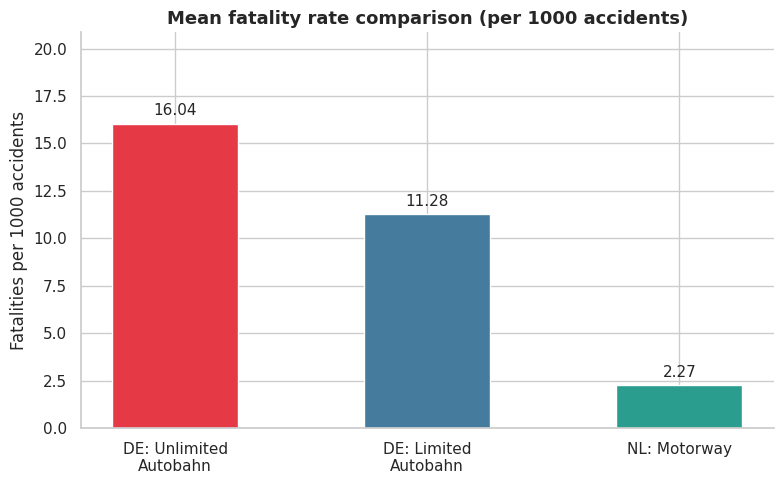

In [6]:
if df_de is not None and df_nl_annual is not None:
    common_years = set(df_de["year"].unique()) & set(df_nl_annual["year"].unique())

    means = {
        "DE: Unlimited\nAutobahn": (
            df_de[df_de["on_unlimited"] & df_de["year"].isin(common_years)]["severity"] == "fatal"
        ).mean()
        * 1000,
        "DE: Limited\nAutobahn": (
            df_de[df_de["on_limited_mw"] & df_de["year"].isin(common_years)]["severity"] == "fatal"
        ).mean()
        * 1000,
        "NL: Motorway": df_nl_annual[df_nl_annual["year"].isin(common_years)]["severity_idx"].mean()
        * 1000,
    }

    colors = ["#e63946", "#457b9d", "#2a9d8f"]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        list(means.keys()), list(means.values()), color=colors, width=0.5, edgecolor="white"
    )
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=11)
    ax.set_title(
        "Mean fatality rate comparison (per 1000 accidents)", fontsize=13, fontweight="bold"
    )
    ax.set_ylabel("Fatalities per 1000 accidents")
    ax.set_ylim(0, max(means.values()) * 1.3)
    sns.despine()
    plt.tight_layout()
    plt.show()

## 5. Methodology notes

- **DE motorway classification:** spatial join with OSM (50m buffer). Unlimited = no `maxspeed` tag or `maxspeed=DE:motorway`.
- **NL motorway classification:** `MAXSNELHD ∈ {100, 120, 130}` + `BEBKOM == 'BU'` from BRON.
- **Rate metric:** fatalities per 1000 accidents. Ideal metric would be per billion vehicle-km but NL vehicle-km by road type is not fully available for the overlap period.
- **Limitations:** GPS accuracy, OSM completeness, different police reporting thresholds between DE and NL.

## 6. Fatal accidents per 100 km of road per year

**Metric:** fatal accident *density* (per 100 km of network), which sidesteps the
recording-threshold problem: fatal accidents are universally captured, so this
allows a fair Germany ↔ Netherlands comparison.

Network lengths used as constants:
- DE unlimited Autobahn: 16,441 km
- DE speed-limited Autobahn: 10,618 km
- NL autosnelwegen: 2,758 km (standard RWS figure)

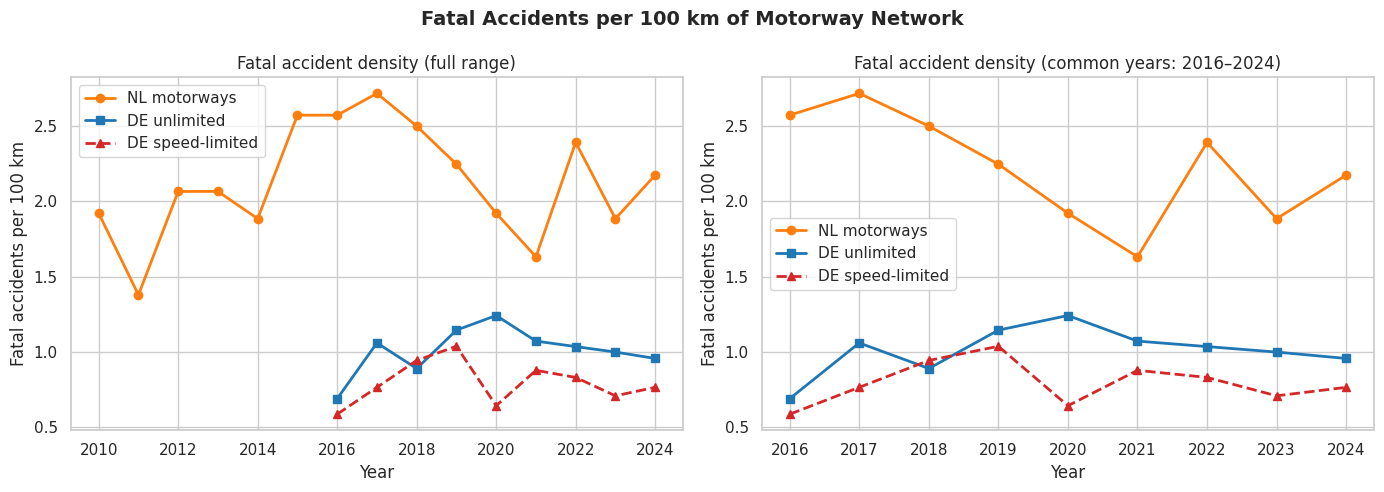

Saved fig07_fatal_accidents_per_100km.png

=== Fatal accident density (fatal accidents / 100 km / year) ===
 year  DE_unlimited  DE_limited    NL
 2010           NaN         NaN 1.922
 2011           NaN         NaN 1.378
 2012           NaN         NaN 2.067
 2013           NaN         NaN 2.067
 2014           NaN         NaN 1.885
 2015           NaN         NaN 2.574
 2016         0.687       0.584 2.574
 2017         1.058       0.763 2.719
 2018         0.888       0.942 2.502
 2019         1.143       1.036 2.248
 2020         1.241       0.640 1.922
 2021         1.070       0.876 1.632
 2022         1.034       0.829 2.393
 2023         0.998       0.706 1.885
 2024         0.955       0.763 2.175


In [7]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")

OUTPUT_FIG = Path("../output/figures")
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)

# ── constants ──────────────────────────────────────────────────────────────────
KM_DE_UNLIMITED = 16_441
KM_DE_LIMITED   = 10_618
KM_NL           = 2_758

# ── DE: fatal accidents per year, by road type ─────────────────────────────────
if df_de is not None:
    de_mw = df_de[df_de["on_motorway"]]
    de_unl = de_mw[de_mw["on_unlimited"]]
    de_lim = de_mw[de_mw["on_limited_mw"]]

    de_unl_fatal = (
        de_unl[de_unl["severity"] == "fatal"]
        .groupby("year").size().rename("fatal_unl")
    )
    de_lim_fatal = (
        de_lim[de_lim["severity"] == "fatal"]
        .groupby("year").size().rename("fatal_lim")
    )
    de_fatal = pd.concat([de_unl_fatal, de_lim_fatal], axis=1).reset_index()
    de_fatal["density_unl"] = de_fatal["fatal_unl"] / KM_DE_UNLIMITED * 100
    de_fatal["density_lim"] = de_fatal["fatal_lim"] / KM_DE_LIMITED   * 100
else:
    de_fatal = pd.DataFrame(columns=["year", "density_unl", "density_lim"])

# ── NL: fatal accidents per year ───────────────────────────────────────────────
if df_nl_annual is not None:
    nl_fatal = df_nl_annual[["year", "fatal"]].copy()
    nl_fatal["density_nl"] = nl_fatal["fatal"] / KM_NL * 100
else:
    nl_fatal = pd.DataFrame(columns=["year", "density_nl"])

# ── plot ───────────────────────────────────────────────────────────────────────
common_years = sorted(set(de_fatal["year"]) & set(nl_fatal["year"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Left: full NL range vs DE range overlay
ax = axes[0]
if not nl_fatal.empty:
    ax.plot(nl_fatal["year"], nl_fatal["density_nl"], marker="o", color="tab:orange",
            label="NL motorways", linewidth=2)
if not de_fatal.empty:
    ax.plot(de_fatal["year"], de_fatal["density_unl"], marker="s", color="tab:blue",
            label="DE unlimited", linewidth=2)
    ax.plot(de_fatal["year"], de_fatal["density_lim"], marker="^", color="tab:red",
            label="DE speed-limited", linewidth=2, linestyle="--")
ax.set_title("Fatal accident density (full range)", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Fatal accidents per 100 km")
ax.legend()

# Right: common years only
ax2 = axes[1]
nl_common  = nl_fatal[nl_fatal["year"].isin(common_years)]
de_common  = de_fatal[de_fatal["year"].isin(common_years)]
if not nl_common.empty:
    ax2.plot(nl_common["year"], nl_common["density_nl"], marker="o", color="tab:orange",
             label="NL motorways", linewidth=2)
if not de_common.empty:
    ax2.plot(de_common["year"], de_common["density_unl"], marker="s", color="tab:blue",
             label="DE unlimited", linewidth=2)
    ax2.plot(de_common["year"], de_common["density_lim"], marker="^", color="tab:red",
             label="DE speed-limited", linewidth=2, linestyle="--")
ax2.set_title(f"Fatal accident density (common years: {common_years[0]}–{common_years[-1]})",
              fontsize=12)
ax2.set_xlabel("Year")
ax2.set_ylabel("Fatal accidents per 100 km")
ax2.legend()

fig.suptitle("Fatal Accidents per 100 km of Motorway Network", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_FIG / "fig07_fatal_accidents_per_100km.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig07_fatal_accidents_per_100km.png")

# Print summary table
print("\n=== Fatal accident density (fatal accidents / 100 km / year) ===")
summary6 = de_fatal[["year", "density_unl", "density_lim"]].rename(
    columns={"density_unl": "DE_unlimited", "density_lim": "DE_limited"})
nl_s = nl_fatal[["year", "density_nl"]].rename(columns={"density_nl": "NL"})
summary6 = summary6.merge(nl_s, on="year", how="outer").sort_values("year")
print(summary6.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

## 7. Accident density — all accidents per 100 km (Germany only)

**Goal:** Disentangle *frequency* from *severity*. Are there simply more accidents on
unlimited sections, or do the same number of crashes just have more lethal outcomes?

We restrict this to Germany only, where both road types are captured by the same
Unfallatlas survey methodology, making the comparison internally consistent.

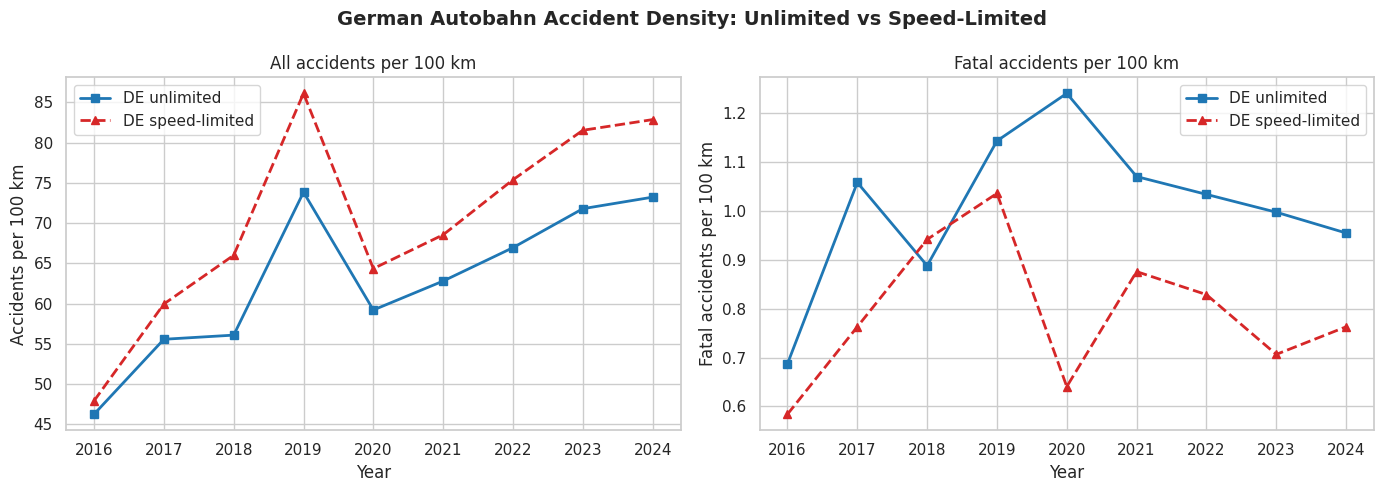

Saved fig08_accident_density_de.png

=== DE accident density (accidents per 100 km / year) ===
 year  total/100km_unl  total/100km_lim  fatal/100km_unl  fatal/100km_lim
 2016           46.256           47.919            0.687            0.584
 2017           55.568           59.955            1.058            0.763
 2018           56.085           66.011            0.888            0.942
 2019           73.846           86.127            1.143            1.036
 2020           59.206           64.353            1.241            0.640
 2021           62.806           68.553            1.070            0.876
 2022           66.955           75.391            1.034            0.829
 2023           71.796           81.541            0.998            0.706
 2024           73.232           82.869            0.955            0.763


In [8]:
if df_de is not None:
    de_mw = df_de[df_de["on_motorway"]]
    de_unl_all = de_mw[de_mw["on_unlimited"]].groupby("year").size().rename("total_unl")
    de_lim_all = de_mw[de_mw["on_limited_mw"]].groupby("year").size().rename("total_lim")
    de_unl_fat = (
        de_mw[de_mw["on_unlimited"] & (de_mw["severity"] == "fatal")]
        .groupby("year").size().rename("fatal_unl")
    )
    de_lim_fat = (
        de_mw[de_mw["on_limited_mw"] & (de_mw["severity"] == "fatal")]
        .groupby("year").size().rename("fatal_lim")
    )

    df7 = pd.concat([de_unl_all, de_lim_all, de_unl_fat, de_lim_fat], axis=1).reset_index()
    df7["total_density_unl"] = df7["total_unl"] / KM_DE_UNLIMITED * 100
    df7["total_density_lim"] = df7["total_lim"] / KM_DE_LIMITED   * 100
    df7["fatal_density_unl"] = df7["fatal_unl"] / KM_DE_UNLIMITED * 100
    df7["fatal_density_lim"] = df7["fatal_lim"] / KM_DE_LIMITED   * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    # Left: total accidents per 100 km
    ax = axes[0]
    ax.plot(df7["year"], df7["total_density_unl"], marker="s", color="tab:blue",
            label="DE unlimited", linewidth=2)
    ax.plot(df7["year"], df7["total_density_lim"], marker="^", color="tab:red",
            label="DE speed-limited", linewidth=2, linestyle="--")
    ax.set_title("All accidents per 100 km", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Accidents per 100 km")
    ax.legend()

    # Right: fatal accidents per 100 km
    ax2 = axes[1]
    ax2.plot(df7["year"], df7["fatal_density_unl"], marker="s", color="tab:blue",
             label="DE unlimited", linewidth=2)
    ax2.plot(df7["year"], df7["fatal_density_lim"], marker="^", color="tab:red",
             label="DE speed-limited", linewidth=2, linestyle="--")
    ax2.set_title("Fatal accidents per 100 km", fontsize=12)
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Fatal accidents per 100 km")
    ax2.legend()

    fig.suptitle("German Autobahn Accident Density: Unlimited vs Speed-Limited",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG / "fig08_accident_density_de.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved fig08_accident_density_de.png")

    print("\n=== DE accident density (accidents per 100 km / year) ===")
    print(df7[["year", "total_density_unl", "total_density_lim",
               "fatal_density_unl", "fatal_density_lim"]]
          .rename(columns={
              "total_density_unl": "total/100km_unl",
              "total_density_lim": "total/100km_lim",
              "fatal_density_unl": "fatal/100km_unl",
              "fatal_density_lim": "fatal/100km_lim",
          })
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("DE data not available.")

## 8. Injury severity pyramid (fatal : serious : slight ratios)

**Goal:** High-speed crashes convert kinetic energy into more severe injuries.
Comparing the *shape* of the injury pyramid (% fatal vs % serious vs % slight)
reflects this physics regardless of how many minor incidents are recorded — making
it the most robust cross-country metric.

**Data note:** The Dutch BRON dataset (`rws_motorway_annual.parquet`) does not
include disaggregated injury severity (serious/slight fields are zero throughout);
only the fatality count is reliably populated alongside property-damage-only
(`material`) accidents. The NL pyramid is therefore shown for *fatalities vs
property-damage-only* as a separate panel, while the full fatal/serious/slight
pyramid uses German data only.

=== Injury severity pyramid (2016–2024 pooled) ===

Group                           Fatal  Serious   Slight    Total   %Fatal %Serious  %Slight
------------------------------------------------------------------------------------------
DE unlimited Autobahn           1,492   18,194   73,329   93,015    1.60%   19.56%   78.84%
DE speed-limited Autobahn         758   11,540   54,884   67,182    1.13%   17.18%   81.69%
NL (fatal vs prop-damage)         553      N/A      N/A  238,952    0.23%     N/A     N/A


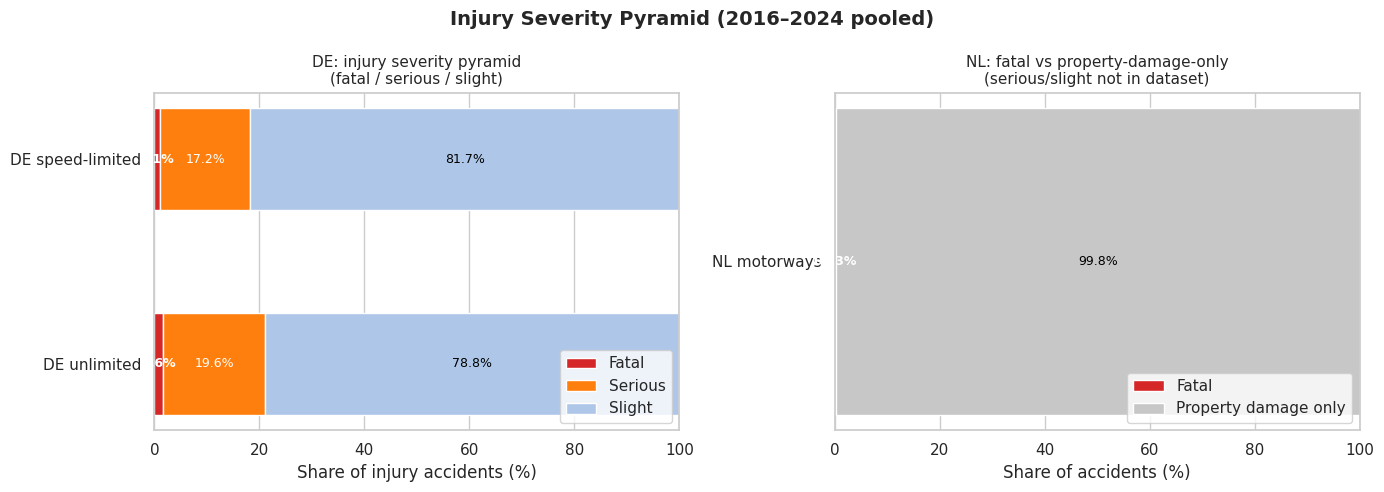


Saved fig09_injury_pyramid.png


In [9]:
# ── German pooled (2016–2024) ──────────────────────────────────────────────────
if df_de is not None:
    de_mw = df_de[df_de["on_motorway"] & df_de["year"].between(2016, 2024)]

    def pyramid_counts(sub_df):
        counts = sub_df["severity"].value_counts()
        fatal   = int(counts.get("fatal",         0))
        serious = int(counts.get("serious_injury", 0))
        slight  = int(counts.get("slight_injury",  0))
        total   = fatal + serious + slight
        if total == 0:
            return dict(fatal=0, serious=0, slight=0,
                        pct_fatal=0, pct_serious=0, pct_slight=0, total=0)
        return dict(
            fatal=fatal, serious=serious, slight=slight,
            pct_fatal  = fatal   / total * 100,
            pct_serious= serious / total * 100,
            pct_slight = slight  / total * 100,
            total=total,
        )

    de_unl_pyr = pyramid_counts(de_mw[de_mw["on_unlimited"]])
    de_lim_pyr = pyramid_counts(de_mw[de_mw["on_limited_mw"]])

    # ── NL pooled (2016–2024), fatal + property-damage only ────────────────────
    nl_pyr = None
    if df_nl_annual is not None:
        nl_sub = df_nl_annual[df_nl_annual["year"].between(2016, 2024)]
        nl_fatal_n    = int(nl_sub["fatal"].sum())
        nl_material_n = int(nl_sub["material"].sum())
        nl_total_n    = nl_fatal_n + nl_material_n
        if nl_total_n > 0:
            nl_pyr = dict(
                fatal=nl_fatal_n,
                material=nl_material_n,
                pct_fatal   = nl_fatal_n    / nl_total_n * 100,
                pct_material= nl_material_n / nl_total_n * 100,
            )

    # ── print summary table ────────────────────────────────────────────────────
    print("=== Injury severity pyramid (2016–2024 pooled) ===\n")
    print(f"{'Group':<28} {'Fatal':>8} {'Serious':>8} {'Slight':>8} {'Total':>8}  "
          f"{'%Fatal':>7} {'%Serious':>8} {'%Slight':>8}")
    print("-" * 90)
    for label, d in [("DE unlimited Autobahn", de_unl_pyr),
                     ("DE speed-limited Autobahn", de_lim_pyr)]:
        print(f"{label:<28} {d['fatal']:>8,} {d['serious']:>8,} {d['slight']:>8,} "
              f"{d['total']:>8,}  {d['pct_fatal']:>6.2f}% {d['pct_serious']:>7.2f}% "
              f"{d['pct_slight']:>7.2f}%")
    if nl_pyr:
        print(f"{'NL (fatal vs prop-damage)':<28} {nl_pyr['fatal']:>8,} {'N/A':>8} {'N/A':>8} "
              f"{nl_total_n:>8,}  {nl_pyr['pct_fatal']:>6.2f}% {'N/A':>7} {'N/A':>7}")

    # ── plot — two panels ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: DE injury pyramid
    groups_de  = ["DE unlimited", "DE speed-limited"]
    pct_fatal  = [de_unl_pyr["pct_fatal"],  de_lim_pyr["pct_fatal"]]
    pct_ser    = [de_unl_pyr["pct_serious"], de_lim_pyr["pct_serious"]]
    pct_sli    = [de_unl_pyr["pct_slight"],  de_lim_pyr["pct_slight"]]

    y_pos = np.arange(len(groups_de))
    bar_h = 0.5
    ax = axes[0]
    b1 = ax.barh(y_pos, pct_fatal, bar_h, label="Fatal",   color="#d62728")
    b2 = ax.barh(y_pos, pct_ser,   bar_h, left=pct_fatal,  label="Serious", color="#ff7f0e")
    b3 = ax.barh(y_pos, pct_sli,   bar_h,
                 left=[a+b for a,b in zip(pct_fatal, pct_ser)],
                 label="Slight", color="#aec7e8")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(groups_de)
    ax.set_xlabel("Share of injury accidents (%)")
    ax.set_xlim(0, 100)
    ax.set_title("DE: injury severity pyramid\n(fatal / serious / slight)", fontsize=11)
    ax.legend(loc="lower right")

    # Add percentage labels inside bars
    for i, (f, s, sl) in enumerate(zip(pct_fatal, pct_ser, pct_sli)):
        if f > 1:
            ax.text(f/2, i, f"{f:.1f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
        mid_s = f + s/2
        if s > 2:
            ax.text(mid_s, i, f"{s:.1f}%", ha="center", va="center", fontsize=9, color="white")
        mid_sl = f + s + sl/2
        if sl > 2:
            ax.text(mid_sl, i, f"{sl:.1f}%", ha="center", va="center", fontsize=9, color="black")

    # Panel 2: NL fatal vs property-damage (note different metric)
    ax2 = axes[1]
    if nl_pyr:
        groups_nl = ["NL motorways"]
        y2 = np.arange(len(groups_nl))
        ax2.barh(y2, [nl_pyr["pct_fatal"]],    bar_h, label="Fatal",         color="#d62728")
        ax2.barh(y2, [nl_pyr["pct_material"]], bar_h,
                 left=[nl_pyr["pct_fatal"]], label="Property damage only", color="#c7c7c7")
        ax2.set_yticks(y2)
        ax2.set_yticklabels(groups_nl)
        ax2.set_xlabel("Share of accidents (%)")
        ax2.set_xlim(0, 100)
        ax2.set_title("NL: fatal vs property-damage-only\n(serious/slight not in dataset)", fontsize=11)
        ax2.legend(loc="lower right")
        ax2.text(nl_pyr["pct_fatal"]/2, 0, f"{nl_pyr['pct_fatal']:.2f}%",
                 ha="center", va="center", fontsize=9, color="white", fontweight="bold")
        ax2.text(nl_pyr["pct_fatal"] + nl_pyr["pct_material"]/2, 0,
                 f"{nl_pyr['pct_material']:.1f}%",
                 ha="center", va="center", fontsize=9, color="black")
    else:
        ax2.text(0.5, 0.5, "NL data not available", transform=ax2.transAxes,
                 ha="center", va="center")

    fig.suptitle("Injury Severity Pyramid (2016–2024 pooled)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG / "fig09_injury_pyramid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nSaved fig09_injury_pyramid.png")
else:
    print("DE data not available.")